In [1]:
import pandas as pd

df = pd.read_csv("../results/vary_k_0_1.csv")

# Inspect
df.head()

,N,K,M,PGEM_acc_mean,PGEM_acc_std,PGEM_wacc_mean,PGEM_wacc_std,PGEM_tau_mean,PGEM_tau_std,BT_acc_mean,...,HTCV_wacc_mean,HTCV_wacc_std,HTCV_tau_mean,HTCV_tau_std,HBTL_acc_mean,HBTL_acc_std,HBTL_wacc_mean,HBTL_wacc_std,HBTL_tau_mean,HBTL_tau_std
0,200,500,25000,0.949724,0.001922,0.993484,0.000582,0.899447,0.003843,0.942085,...,0.993554,0.000608,0.899608,0.003769,0.949925,0.001965,0.993590,0.000608,0.899849,0.003929
1,200,1000,25000,0.944955,0.003481,0.992389,0.000878,0.889910,0.006963,0.941673,...,0.992434,0.000733,0.890764,0.005581,0.945302,0.003075,0.992393,0.000834,0.890603,0.006151
2,200,2000,25000,0.940462,0.003134,0.991120,0.000868,0.880925,0.006269,0.941588,...,0.990382,0.001198,0.876794,0.006802,0.939347,0.002806,0.990720,0.000952,0.878693,0.005612
3,200,3000,25000,0.932935,0.004949,0.989125,0.001900,0.865869,0.009897,0.940427,...,0.987245,0.002345,0.853186,0.010800,0.926673,0.004889,0.987125,0.002276,0.853347,0.009778
4,200,4000,25000,0.928925,0.003643,0.987937,0.001569,0.857849,0.007285,0.941432,...,0.985479,0.001971,0.843005,0.008454,0.919035,0.004538,0.984552,0.002261,0.838070,0.009076


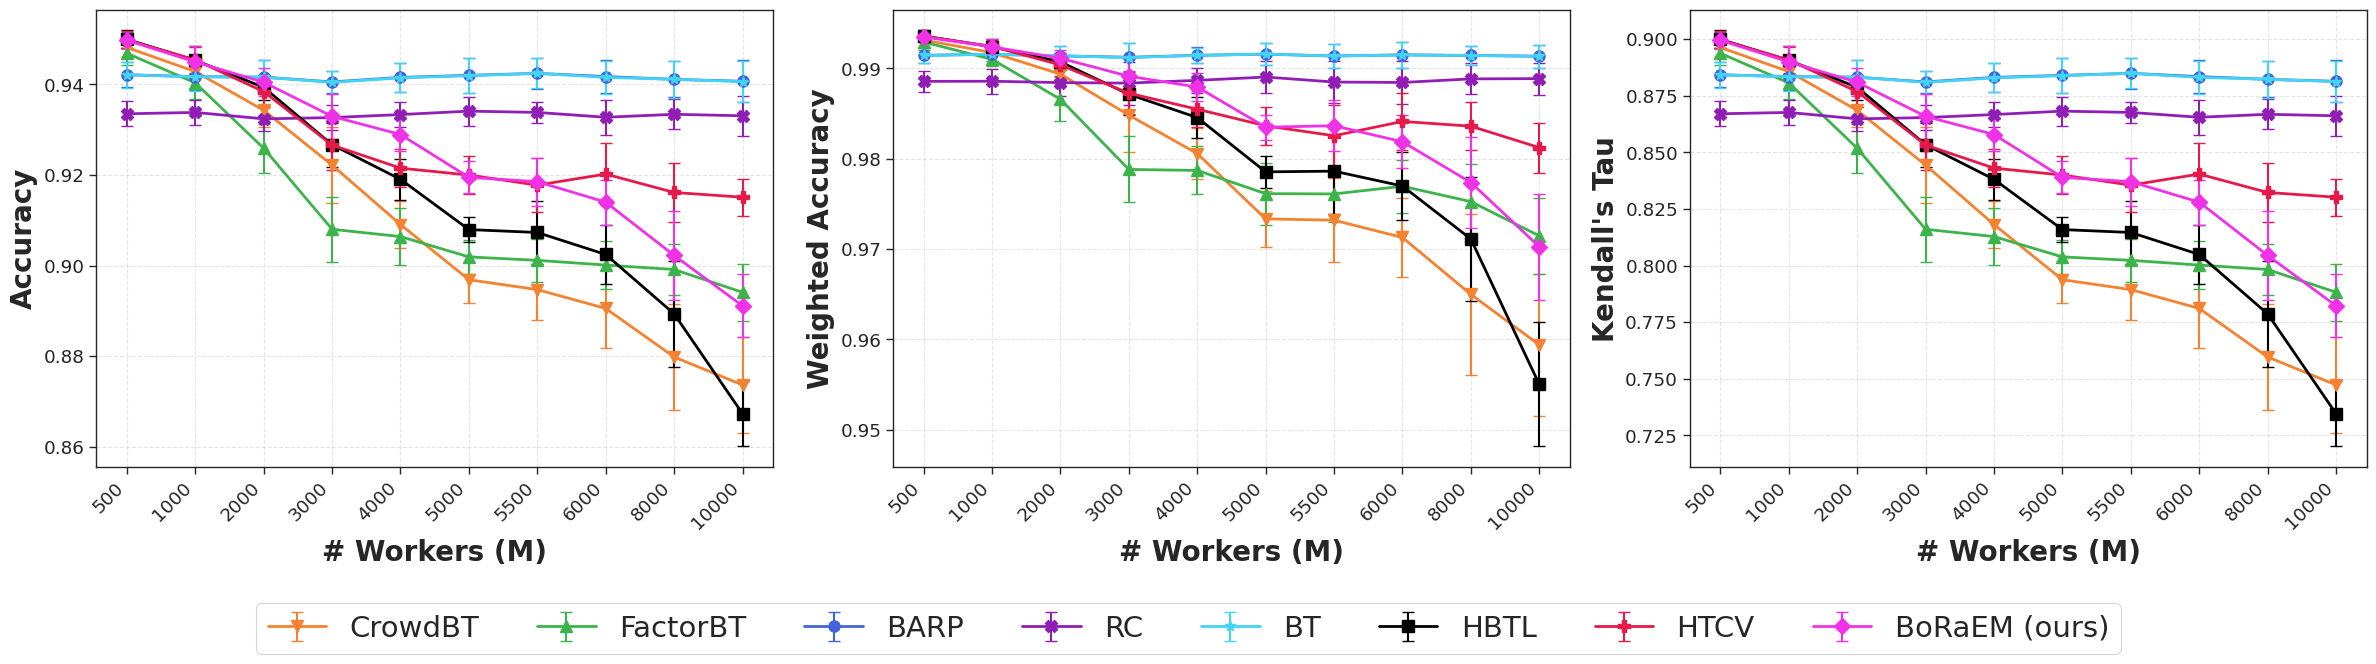

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure N and K are treated as integers
df['K'] = df['K'].astype(int)

# Create "Setting" column for the X-axis label in (N, K) format
df['Setting'] = df['K'].astype(str)

# Sort the dataframe
df = df.sort_values(by=['K'])

# Extract the sorted settings and create an index for plotting
settings_order = df['Setting'].values
x_indices = np.arange(len(settings_order))

# Define the parameters
methods = ['CrowdBT', 'FactorBT', 'BARP', 'RC', 'BT','HBTL', 'HTCV', 'PGEM']
metrics = ['acc', 'wacc', 'tau']

# Display names for the legend
method_display = {
    'CrowdBT': 'CrowdBT',
    'FactorBT': 'FactorBT',
    'BARP': 'BARP',
    'RC': 'RC',
    'BT': 'BT',
    'HBTL': 'HBTL',
    'HTCV': 'HTCV',
    'PGEM': 'BoRaEM (ours)'
}

# Six distinct high-contrast colors
colors = ["#F58231" , "#3CB44B", "#4363D8", "#911EB4", "#42D4F4", "#010000", "#E6194B", "#F032E6"]



# colors = sns.color_palette("husl", len(methods))
markers = ['v',  '^', 'o', 'X', '*', 's', 'P', 'D']

# Styling
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5)

# Create a single figure with 3 subplots stacked vertically
# sharex=True ensures that only the bottom plot needs x-labels
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharex=True)
title_map = {'acc': 'Accuracy', 'wacc': 'Weighted Accuracy', 'tau': "Kendall's Tau"}

handles, labels = [], []

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    for j, method in enumerate(methods):
        mean_col = f"{method}_{metric}_mean"
        std_col = f"{method}_{metric}_std"
        
        means = df[mean_col].values
        stds = df[std_col].values
        
        line = ax.errorbar(
            x_indices, means, yerr=stds,
            label=method_display[method],
            marker=markers[j], markersize=8,
            capsize=4, elinewidth=1.5, linewidth=2,
            color=colors[j]
        )
        
        # Collect handles for the legend from the first subplot
        if i == 0:
            handles.append(line)
            labels.append(method_display[method])
        
    # Formatting each subplot
    ax.set_ylabel(title_map.get(metric, metric.upper()), fontsize=20, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Only show the X-axis labels on the bottom subplot
#     if i == 2:
    ax.set_xticks(x_indices)
    ax.set_xticklabels(settings_order, rotation=45, ha='right')
    ax.set_xlabel('# Workers (M)', fontsize=20, fontweight='bold')

# Add a single legend for the entire figure at the top
fig.legend(handles, labels, title="", loc='upper center', 
           bbox_to_anchor=(0.5, 0), ncol=8, 
           fontsize=21, title_fontsize=21, frameon=True)

plt.tight_layout()

os.makedirs("svgs",exist_ok=True)
os.makedirs("pdfs",exist_ok=True)

# --- SAVING AS SVG AND PDF ---
# Saving as SVG (Scalable Vector Graphics)
plt.savefig('svgs/vary_k_0_1.svg', format='svg', bbox_inches='tight')

# Saving as PDF
plt.savefig('pdfs/vary_k_0_1.pdf', format='pdf', bbox_inches='tight')

plt.show()

In [3]:
import pandas as pd

import pandas as pd

df = pd.read_csv("../results/vary_k_-1_1.csv")
df.head()

,N,K,M,PGEM_acc_mean,PGEM_acc_std,PGEM_wacc_mean,PGEM_wacc_std,PGEM_tau_mean,PGEM_tau_std,BT_acc_mean,...,HTCV_wacc_mean,HTCV_wacc_std,HTCV_tau_mean,HTCV_tau_std,HBTL_acc_mean,HBTL_acc_std,HBTL_wacc_mean,HBTL_wacc_std,HBTL_tau_mean,HBTL_tau_std
0,200,500,25000,0.947930,0.001354,0.993709,0.000454,0.895859,0.002707,0.536638,...,0.987840,0.001866,0.857648,0.007110,0.948744,0.001762,0.993914,0.000416,0.897487,0.003524
1,200,1000,25000,0.944503,0.003728,0.993042,0.001247,0.889005,0.007457,0.501854,...,0.986653,0.002423,0.848764,0.006891,0.944799,0.003927,0.993181,0.001174,0.889598,0.007855
2,200,2000,25000,0.939869,0.004484,0.991830,0.001437,0.879739,0.008968,0.477829,...,0.980791,0.003685,0.818312,0.012913,0.938382,0.005202,0.991425,0.001607,0.876764,0.010404
3,200,3000,25000,0.932819,0.003520,0.989458,0.001849,0.865638,0.007039,0.484191,...,0.972329,0.007719,0.780322,0.016575,0.927900,0.003827,0.987880,0.002305,0.855799,0.007654
4,200,4000,25000,0.927030,0.004011,0.988392,0.001775,0.854060,0.008022,0.487894,...,0.953498,0.017457,0.729789,0.049944,0.917754,0.004713,0.984990,0.002187,0.835515,0.009412


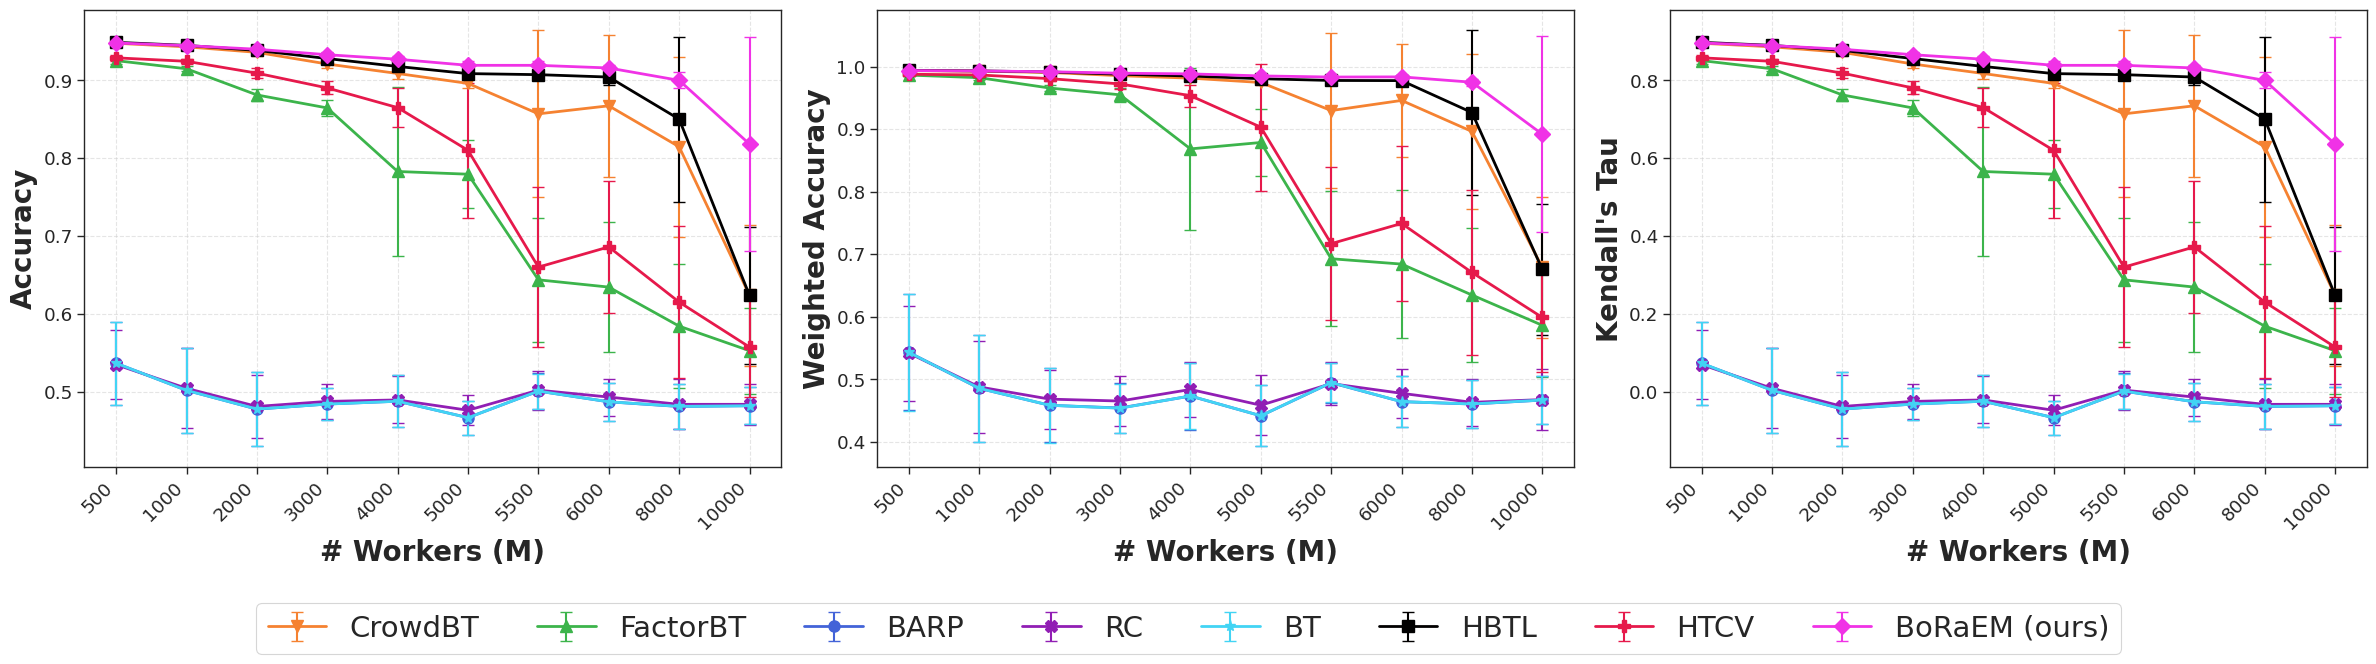

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure N and K are treated as integers
df['K'] = df['K'].astype(int)

# Create "Setting" column for the X-axis label in (N, K) format
df['Setting'] = df['K'].astype(str)

# Sort the dataframe
df = df.sort_values(by=['K'])

# Extract the sorted settings and create an index for plotting
settings_order = df['Setting'].values
x_indices = np.arange(len(settings_order))

# Define the parameters
methods = ['CrowdBT', 'FactorBT', 'BARP', 'RC', 'BT','HBTL', 'HTCV', 'PGEM']
metrics = ['acc', 'wacc', 'tau']

# Six distinct high-contrast colors
colors = ["#F58231" , "#3CB44B", "#4363D8", "#911EB4", "#42D4F4", "#010000", "#E6194B", "#F032E6"]



# colors = sns.color_palette("husl", len(methods))
markers = ['v',  '^', 'o', 'X', '*', 's', 'P', 'D']

# Styling
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5)

# Create a single figure with 3 subplots stacked vertically
# sharex=True ensures that only the bottom plot needs x-labels
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharex=True)
title_map = {'acc': 'Accuracy', 'wacc': 'Weighted Accuracy', 'tau': "Kendall's Tau"}

handles, labels = [], []

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    for j, method in enumerate(methods):
        mean_col = f"{method}_{metric}_mean"
        std_col = f"{method}_{metric}_std"
        
        means = df[mean_col].values
        stds = df[std_col].values
        
        line = ax.errorbar(
            x_indices, means, yerr=stds,
            label=method_display[method],
            marker=markers[j], markersize=8,
            capsize=4, elinewidth=1.5, linewidth=2,
            color=colors[j]
        )
        
        # Collect handles for the legend from the first subplot
        if i == 0:
            handles.append(line)
            labels.append(method_display[method])
        
    # Formatting each subplot
    ax.set_ylabel(title_map.get(metric, metric.upper()), fontsize=20, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Only show the X-axis labels on the bottom subplot
#     if i == 2:
    ax.set_xticks(x_indices)
    ax.set_xticklabels(settings_order, rotation=45, ha='right')
    ax.set_xlabel('# Workers (M)', fontsize=20, fontweight='bold')

# Add a single legend for the entire figure at the top
fig.legend(handles, labels, title="", loc='upper center', 
           bbox_to_anchor=(0.5, 0), ncol=8, 
           fontsize=21, title_fontsize=21, frameon=True)

plt.tight_layout()

os.makedirs("svgs",exist_ok=True)
os.makedirs("pdfs",exist_ok=True)

# --- SAVING AS SVG AND PDF ---
# Saving as SVG (Scalable Vector Graphics)
plt.savefig('svgs/vary_k_-1_1.svg', format='svg', bbox_inches='tight')

# Saving as PDF
plt.savefig('pdfs/vary_k_-1_1.pdf', format='pdf', bbox_inches='tight')

plt.show()